## 1. Environment & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import os

np.random.seed(42)

dataset_path = "../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(dataset_path)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded dataset with 253680 rows and 22 columns.


## 2. Preprocessing & Feature Scaling

In [2]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Data split and scaled successfully.
Train size: 202944, Test size: 50736


## 3. Class Imbalance Math & Model Initialization

In [3]:
neg_class = (y_train == 0).sum()
pos_class = (y_train == 1).sum()
scale_weight = float(neg_class / pos_class)
print(f"Calculated scale_pos_weight for XGBoost: {scale_weight:.4f}")

lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42, n_jobs=-1)
xgb_model = XGBClassifier(scale_pos_weight=scale_weight, eval_metric="logloss", random_state=42, n_jobs=-1)

Calculated scale_pos_weight for XGBoost: 6.1770


## 4. Train Models & Soft Voting Ensemble

In [4]:
print("Training Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train)

print("Training Soft Voting Ensemble...")
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft',
    n_jobs=-1
)
ensemble_model.fit(X_train_scaled, y_train)
print("All models trained successfully.")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training Soft Voting Ensemble...
All models trained successfully.


## 5. IEEE-Quality ROC Curve Generation

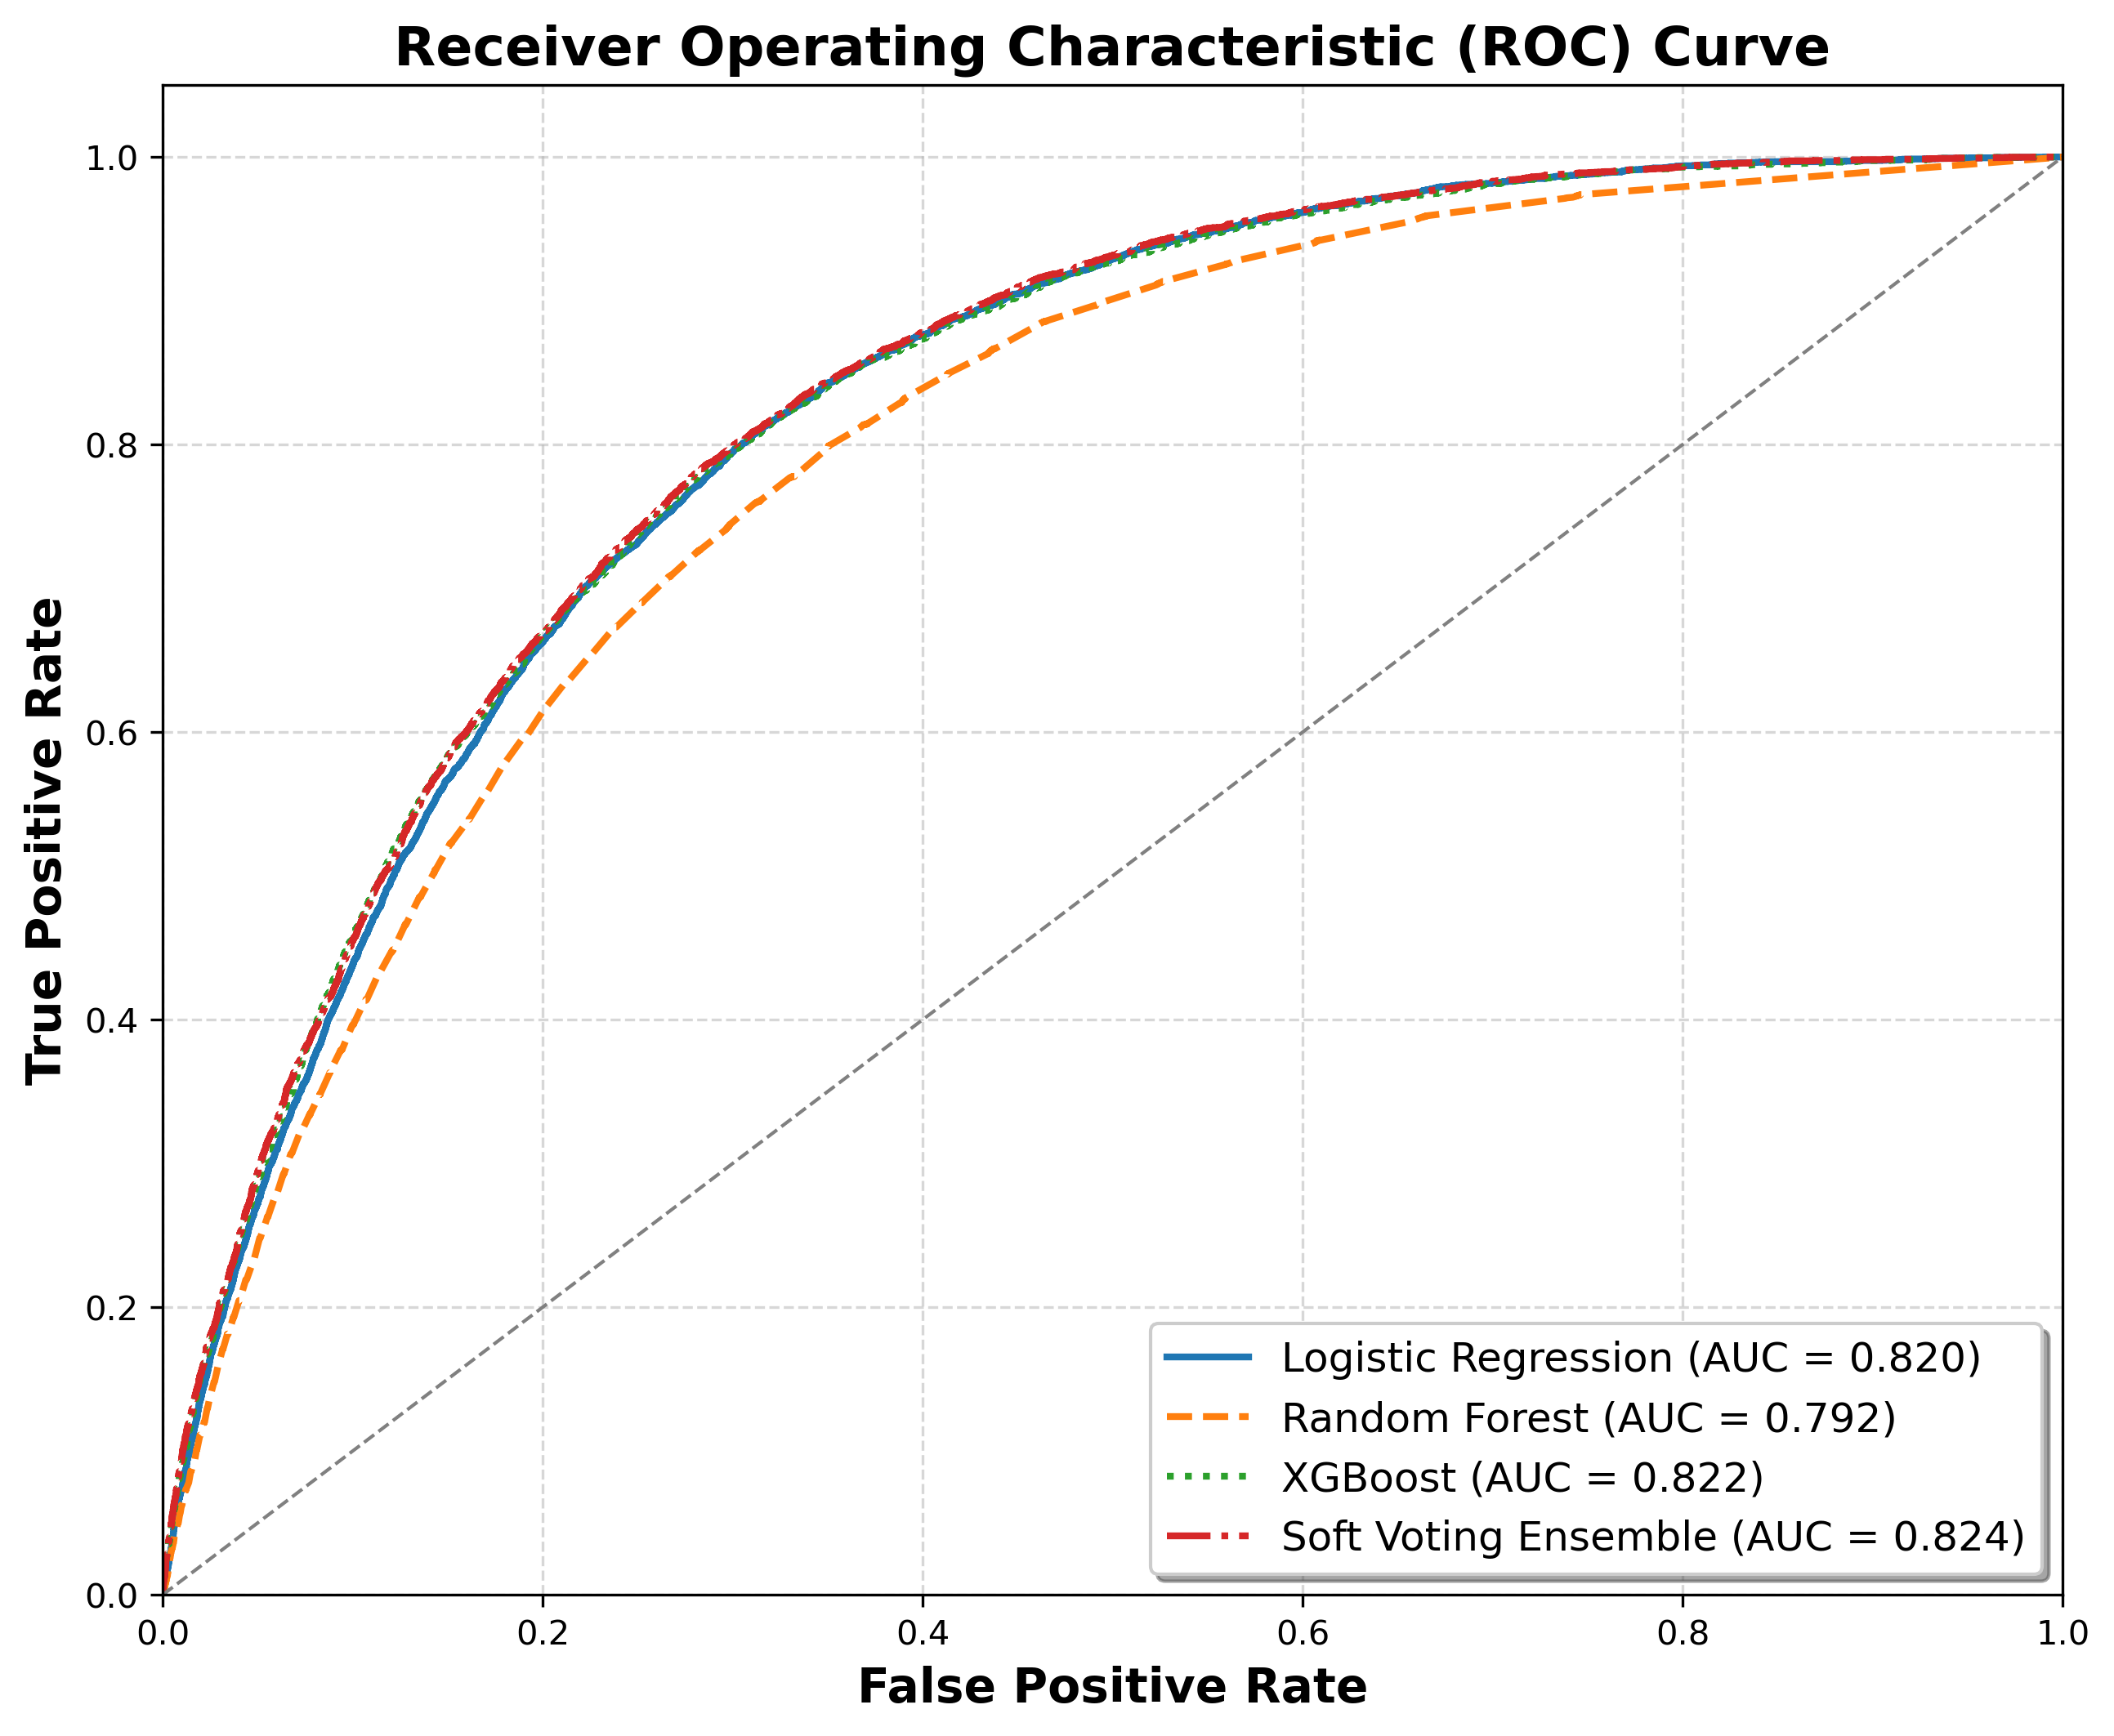

Saved IEEE-ready high-res ROC curves.


In [5]:
plt.figure(figsize=(10, 8), dpi=300)

models = {
    "Logistic Regression": (lr_model, "-"),
    "Random Forest": (rf_model, "--"),
    "XGBoost": (xgb_model, ":"),
    "Soft Voting Ensemble": (ensemble_model, "-.")
}

for name, (model, linestyle) in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle=linestyle, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, weight='bold')
plt.ylabel('True Positive Rate', fontsize=14, weight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, weight='bold')
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

os.makedirs("../output/figures", exist_ok=True)
plt.savefig("../output/figures/roc_curve_centralized.pdf", format="pdf", bbox_inches="tight")
plt.savefig("../output/figures/roc_curve_centralized.png", format="png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved IEEE-ready high-res ROC curves.")